# Investigating MNIST RLCT values using NGD and SGD

This notebook is the first in the MARS research project led by Moosa Saghir, Zach Liu, and Ragha Rao, investigating the central claim of SLT - namely that SGD converges towards sets of model parameters that yield a lower model complexity. To this end, we will use both the "real log canonical threshold" (RLCT) and the Hessian to measure model complexity.

If SLT predictions are correct, we expect that SGD will yield models with lower Hessian eigenvalues and a lower RLCT value, compared to NGD (natural gradient descent, which is a modified variant of gradient descent that premultiplies the loss gradient with the inverse of the Fisher information matrix).

## Methodology

We use a very simple network architecture:
*   128 neuron hidden layer
*   ReLU activation
*   Dropout with 0.5 probability
*   10 neuron output layer
*   Return log softmax probabilities

In future notebooks, we will also train small transformer models and CNNs. But for now we'll stick to a simple example to get started.

For different model architectures, we train the model using various gradient descent algorithms, including: SGD, Momentum, Adam, and NGD. We then calculate the Hessian and the RLCT at the minima converged to. This will allow comparison of the model complexities achieved by different gradient descent algorithms.

## Work in progress
* Need to vary model architecture and see how this affects RLCT
* Need to calculate Hessian for different optimizers / architectures

## Setup

### Linux / MacOS

These instructions will be written with Ubuntu in mind, although MacOS should be quite similar. The notebook should be run locally using VSCode, and you'll need to install Anaconda to use `conda` virtual environments (`venv`).

1. In the terminal, create a venv with a name of your choice, and activate it:

```bash
conda create --name env_name python=3.10
conda activate env_name
```

2. Install packages:

```bash
conda install einops wandb tqdm ipykernel
```

If some of them don't install, then try running `pip install` in the terminal. If this still doesn't work, then run `!pip install <module_name>` in the notebook itself.

3. Create a kernel for the virtual environment:

```bash
python -m ipykernel install --user --name env_name --display-name "Python (env_name)"
```

4. In VSCode, go to the top-right of the notebook, and select the kernel name you created. It will be in "local kernels".

5. Clone the repository into your VSCode workspace:

```
git clone https://github.com/cxtraa/ngd_with_slt.git
```

6. Remember to regularly pull/push changes using: 

``` bash
git pull origin main
git push origin main
```

7. When using `wandb`, you will be prompted for an API key. Follow the provided instructions, and you should be able to access the team "slt_to_the_moon".

In [ ]:
# Install dependencies
!pip install devinterp torch torchvision tqdm

In [1]:
# Import required libraries

import os
import sys
import numpy as np
import einops

import torch as t
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split

from tqdm import tqdm
from datetime import datetime
import json
import wandb

from devinterp.slt import estimate_learning_coeff
from devinterp.optim.sgld import SGLD

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

device = "cuda" if t.cuda.is_available() else "cpu"

In [2]:
# Useful constants

PROJECT_NAME = "mnist dense nn"
TEAM_NAME = "slt_to_the_moon"

In [3]:
# Initialise wandb

wandb.login()
wandb.init(project=PROJECT_NAME,
           entity=TEAM_NAME,
           name="test run 3",
           )

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: moosasaghir10 (slt_to_the_moon). Use `wandb login --relogin` to force relogin


In [4]:
# Define MNIST model architecture

class NeuralNet(nn.Module):
    """
    Simple template NN architecture.
    Adjust architecture accordingly for experiment.
    """
    
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet().to(device)
print(model)

NeuralNet(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [5]:
# Define model hyperparameters, loss function, and optimizers

hyperparams = {
    "lr": 1e-5,
    "batch_size" : 32,
    "num_epochs" : 20,  # MUST BE AT LEAST 5 AS RLCT ESTIMATE TAKES AVERAGE OF LAST 5 EPOCHS
    "momentum" : 0.8,
    "num_draws" : 300,
    "num_chains" : 5,
    "noise_level" : 0.5,
    "elasticity" : 50,
}

epochs = np.arange(1, hyperparams["num_epochs"]+1)

criterion = nn.CrossEntropyLoss()
sgd = t.optim.SGD(
    model.parameters(),
    lr=hyperparams["lr"],
    )
adam = t.optim.Adam(
    model.parameters(),
    lr=hyperparams["lr"],
    )
rmsprop = t.optim.RMSprop(
    model.parameters(),
    lr=hyperparams["lr"],
    momentum=hyperparams["momentum"],
)

optimizers = [adam, rmsprop]

In [25]:
# Setup hyperparameter sweep for RLCT estimation

sweep_config = {
    "method" : "random",
    "name" : "sweep",
    "parameters" : {
        "elasticity" : {
            "distribution" : "log_uniform_values",
            "min" : 1e0,
            "max" : 1e4,
        },
        "noise_level" : {
            "distribution" : "log_uniform_values",
            "min" : 1e-1,
            "max" : 1e2,
        },
        "num_draws" : {
            "distribution" : "q_uniform",
            "min" : 1e2,
            "max" : 1e3,
        },
        "num_chains" : {
            "distribution" : "int_uniform",
            "min" : 1,
            "max" : 10,
        }, 
    }, 
}

In [6]:
# Load MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""data', train=False, download=True, transform=transform)

train_loader = t.utils.data.DataLoader(train_set, batch_size=hyperparams["batch_size"], shuffle=True)
test_loader = t.utils.data.DataLoader(test_set, batch_size=hyperparams["batch_size"], shuffle=False)

In [7]:
# Define training and evaluation functions

def train_one_epoch(model, train_loader, optimizer, criterion):
    """"
    Train one epoch of a model.
    `model`: the nn.Module to be trained,
    `train_loader`: the PyTorch DataLoader for the training data,
    `optimizer` : the optimizer class used,
    `criterion` : loss function.
    """
    
    model.train()
    train_loss = 0
    for image, label in tqdm(train_loader):
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    return train_loss / len(train_loader)

def evaluate(model, test_loader, criterion):
    """
    Evaluate the model with testing data.
    `model` : model to test,
    `test_loader` : PyTorch DataLoader for test data,
    `criterion` : loss function.
    """

    model.eval()
    test_loss = 0
    with t.no_grad():
        for image, label in test_loader:
            image, label = image.to(device), label.to(device)
            output = model(image)
            loss = criterion(output, label)
            test_loss += loss.item()
    return test_loss / len(test_loader)


In [8]:
# For each optimiser, train the model and record train and test losses.

models = {}
train_losses = {}
test_losses = {}
for optimizer in optimizers:
    name = f"{optimizer.__class__.__name__}"
    optim_models = []
    optim_train_losses = []
    optim_test_losses = []
    print(f"\n======================== Training with {name} ==========================")
    for epoch in range(hyperparams["num_epochs"]):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        test_loss = evaluate(model, test_loader, criterion)
        optim_train_losses.append(train_loss)
        optim_test_losses.append(test_loss)
        optim_models.append(model)
        print(f"Epoch {epoch+1}/{hyperparams['num_epochs']}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")
    train_losses[name] = optim_train_losses
    test_losses[name] = optim_test_losses
    models[name] = optim_models


======================== Training with Adam ==========================


100%|██████████| 1875/1875 [00:11<00:00, 169.77it/s]


Epoch 1/20: train_loss=1.0649, test_loss=0.4941


100%|██████████| 1875/1875 [00:10<00:00, 173.68it/s]


Epoch 2/20: train_loss=0.4312, test_loss=0.3640


...

100%|██████████| 1875/1875 [00:10<00:00, 172.71it/s]


Epoch 20/20: train_loss=0.1305, test_loss=0.1318

======================== Training with RMSprop ==========================


100%|██████████| 1875/1875 [00:10<00:00, 176.46it/s]


Epoch 1/20: train_loss=0.1307, test_loss=0.1235


 77%|███████▋  | 1438/1875 [00:08<00:02, 177.66it/s]

In [45]:
# Send training and testing data to wandb

train_fig = go.Figure()
for optim, train_loss in train_losses.items():
    train_fig.add_trace(go.Scatter(x=epochs, y=train_loss, mode='lines+markers', name=optim))

train_fig.update_layout(title="Training loss",
                  xaxis_title="Epoch",
                  yaxis_title="Loss",
                  legend_title="Optimizers",
                  )
wandb.log({"Training Losses" : train_fig})

test_fig = go.Figure()
for optim, test_loss in test_losses.items():
    test_fig.add_trace(go.Scatter(x=epochs, y=test_loss, mode='lines+markers', name=optim))

test_fig.update_layout(title="Test loss",
                  xaxis_title="Epoch",
                  yaxis_title="Loss",
                  legend_title="Optimizers",
                  )
wandb.log({"Test Losses" : test_fig})

In [46]:
# STANDARD RLCT MEASUREMENT WITH FIXED HYPERPARAMETERS

rlct_estimates = {}
for optimizer in models:    
    print(f"======================== RLCT estimates for {optimizer} ==========================")
    for m in models[optimizer]:
        rlct_estimate = estimate_learning_coeff(
            m,
            train_loader,
            criterion=criterion,
            optimizer_kwargs=dict(
                lr=hyperparams["lr"],
                noise_level=hyperparams["noise_level"],
                elasticity=hyperparams["elasticity"],
                num_samples=len(train_set),
                temperature="adaptive",
            ),
            sampling_method=SGLD,
            num_chains=hyperparams["num_chains"],
            num_draws=hyperparams["num_draws"],
            num_burnin_steps=0,
            num_steps_bw_draws=1,
            device=device,
        )
        if optimizer in rlct_estimates:
            rlct_estimates[optimizer].append(rlct_estimate)
        else:
            rlct_estimates[optimizer] = [rlct_estimate]
        print(f"RLCT estimate: {rlct_estimate}")
    average_rlct_estimate = np.sum(rlct_estimates[optimizer][-5:])/5        
    wandb.log({"optimizer" : optimizer, "rlct_estimate" : average_rlct_estimate})
    print(f"======== FINAL RLCT ESTIMATE FOR {optimizer} : {average_rlct_estimate} ========")


======================== RLCT estimates for Adam ==========================


Chain 0: 100%|██████████| 400/400 [00:03<00:00, 113.72it/s]


RLCT estimate: 2255.292724609375


Chain 0: 100%|██████████| 400/400 [00:03<00:00, 112.65it/s]


RLCT estimate: 1989.2525634765625


...

RLCT estimate: 1902.98388671875


Chain 0: 100%|██████████| 400/400 [00:03<00:00, 117.46it/s]


RLCT estimate: 1601.251953125


Chain 0: 100%|██████████| 400/400 [00:03<00:00, 111.11it/s]

RLCT estimate: 49.944252014160156
###### FINAL RLCT ESTIMATE FOR RMSprop : 1434.990071105957 ######


In [20]:
# HYPERPARAMETER SWEEP FOR RLCT MEASUREMENTS

def wandb_rlct_estimation():
    """
    Used in hyperparameter sweep.
    Estimate RLCT for the first optimizer only using random hyperparameters for SGLD.
    """
    rlct_estimates = {}
    with wandb.init() as run:
        config = run.config
        for optimizer in ["Adam"]:    
            print(f"======================== RLCT estimates for {optimizer} ==========================")
            for m in models[optimizer]:
                rlct_estimate = estimate_learning_coeff(
                    m,
                    train_loader,
                    criterion=criterion,
                    optimizer_kwargs=dict(
                        lr=hyperparams["lr"],
                        noise_level=config.noise_level,
                        elasticity=config.elasticity,
                        num_samples=len(train_set),
                        temperature="adaptive",
                    ),
                    sampling_method=SGLD,
                    num_chains=config.num_chains,
                    num_draws=config.num_draws,
                    num_burnin_steps=0,
                    num_steps_bw_draws=1,
                    device=device,
                )
                if optimizer in rlct_estimates:
                    rlct_estimates[optimizer].append(rlct_estimate)
                else:
                    rlct_estimates[optimizer] = [rlct_estimate]
            average_rlct_estimate = np.sum(rlct_estimates[optimizer][-5:])/5        
            wandb.log({"optimizer" : optimizer, "rlct_estimate" : average_rlct_estimate})
            print(f"###### FINAL RLCT ESTIMATE FOR {optimizer} : {average_rlct_estimate} ######")

In [21]:
# RUN HYPERPARAMETER SWEEP

hyperparam_sweep_2 = wandb.sweep(sweep_config, project=PROJECT_NAME)
wandb.agent(hyperparam_sweep_2, wandb_rlct_estimation)

Create sweep with ID: smgin0gf
Sweep URL: https://wandb.ai/slt_to_the_moon/mnist%20dense%20nn/sweeps/smgin0gf


wandb: Agent Starting Run: qm7hewai with config:
wandb: 	elasticity: 1.5332849398047217
wandb: 	noise_level: 0.4384474331064818
wandb: 	num_chains: 5
wandb: 	num_draws: 587
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


======================== RLCT estimates for Adam ==========================


Chain 4: 100%|██████████| 587/587 [00:04<00:00, 137.48it/s]


###### FINAL RLCT ESTIMATE FOR Adam : -201.29953002929688 ######


...

======================== RLCT estimates for Adam ==========================


Chain 5: 100%|██████████| 163/163 [00:01<00:00, 124.05it/s]


###### FINAL RLCT ESTIMATE FOR Adam : nan ######


optimizer,Adam
rlct_estimate,nan


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


In [ ]:
# Save data as a bar plot to wandb

optimizer_rlct_vals = [[key, value[-1]] for key, value in rlct_estimates.items()]
table = wandb.Table(data=optimizer_rlct_vals, columns=["optimizer", "rlct"])
wandb.log({"rlct for optimizers" : wandb.plot.bar(table, "optimizer", "rlct", title="Final RLCT values for different optimizers")})

In [11]:
# Save RLCT estimates data to wandb

rlct_fig = go.Figure()

for optim, rlct_estimate in rlct_estimates.items():
    rlct_fig.add_trace(go.Scatter(x=epochs, y=rlct_estimate, mode='lines+markers', name=optim))

train_fig.update_layout(title="RLCT estimate",
                  xaxis_title="Epoch",
                  yaxis_title="RLCT",
                  legend_title="Optimizers",
                  )

wandb.log({"RLCT Estimates" : rlct_fig})

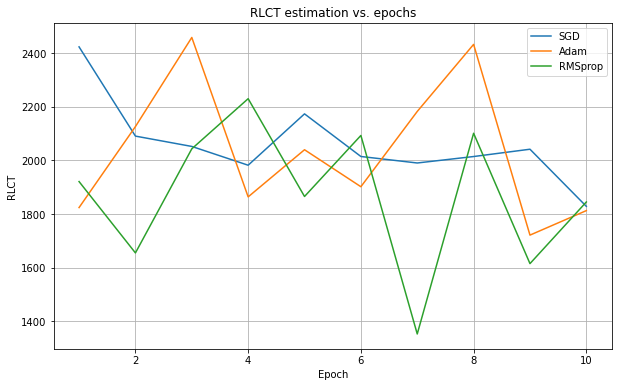

In [12]:
# Quick graphs to visualise how RLCT evolved over time

plt.figure(figsize=(10, 6))
for optim in rlct_estimates:
    data = {"Epochs" : np.arange(1, hyperparams["num_epochs"]+1), optim : rlct_estimates[optim]}
    plt.plot(np.arange(1, hyperparams["num_epochs"]+1), rlct_estimates[optim], label=optim)
plt.grid()
plt.title("RLCT estimation vs. epochs")
plt.xlabel("Epoch")
plt.ylabel("RLCT")
plt.legend()